In [1]:
"""
LSTM Flood Forecasting Model (PyTorch)
Predicts streamflow 24 hours (1 day) in advance using historical weather and streamflow data.
Target: streamflow_cfs_target_24h

Downloads preprocessed data from the W&B artifact produced by missouri_preprocessing.py
"""
import torch
import polars as pl
import wandb
import numpy as np
import joblib
from SRC.helper_functions.preprocessing import processor

config = {
    "input_cols": [
        "latitude",
        "longitude",
        "streamflow_cfs_mean",
        "gage_height_ft_mean",
        "precipitation_mm",
        "temperature_c",
        "specific_humidity_kgkg",
    ], 
    "target": "streamflow_cfs_target_24h",
    "train_split": 0.8,
    "val_split": 0.9,
    "start_date": "2015-01-01",
    "end_date": "2020-12-31",
    "file_path": "flood-dataset-missouri",
    "file_name": "flood_model_missouri",
    "table": "wandb.flood_model_missouri",
    "lag_window": 7,
    "frequency": "daily",
    "split_time_days": 30
}

pcr = processor(config)
pcr.pull_wandb()
print(pcr.df["site_id"].unique())
print(pcr.df.shape)
train_X, val_X, test_X, train_y, val_y, test_y = pcr.return_outputs()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\sacha\_netrc.
wandb: Downloading large artifact 'flood-dataset-missouri:latest', 604.73MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.4 (1679.8MB/s)


shape: (89,)
Series: 'site_id' [str]
[
	"06935770"
	"06928359"
	"06893578"
	"06821080"
	"06904650"
	…
	"06893820"
	"06923940"
	"06899700"
	"06893500"
	"06917560"
]
(176079, 51)


In [2]:

WINDOW_SIZE = 14

def create_sequences(X, y, site_ids, window_size):
    """Create sliding window sequences per site.

    For each site, slides a window of `window_size` hours across the data.
    Each sequence uses `window_size` hours of features to predict the target
    at the last timestep.

    Returns:
        X_seq: array of shape (num_sequences, window_size, num_features)
        y_seq: array of shape (num_sequences,)
    """
    X_sequences, y_sequences = [], []
    unique_sites = np.unique(site_ids)

    for site in unique_sites:
        mask = site_ids == site
        site_X = X[mask]
        site_y = y[mask]

        # Only create sequences if site has enough data
        if len(site_X) < window_size:
            continue

        for i in range(len(site_X) - window_size):
            X_sequences.append(site_X[i : i + window_size])
            y_sequences.append(site_y[i + window_size - 1])

    return np.array(X_sequences), np.array(y_sequences)

In [3]:
# Get site ids from train_X
train_sites = train_X["site_id"].to_numpy()
val_sites = val_X["site_id"].to_numpy()
test_sites = test_X["site_id"].to_numpy()

# Drop site_id and observation_hour columns
drop_cols = ["site_id", "observation_hour"]
train_X_arr = train_X.drop(drop_cols).to_numpy()
val_X_arr = val_X.drop(drop_cols).to_numpy()
test_X_arr = test_X.drop(drop_cols).to_numpy()
train_y_arr = train_y.to_numpy()
val_y_arr = val_y.to_numpy()
test_y_arr = test_y.to_numpy()

print("\nCreating sequences...")
X_train, y_train = create_sequences(train_X_arr, train_y_arr, train_sites, WINDOW_SIZE)
X_val, y_val = create_sequences(val_X_arr, val_y_arr, val_sites, WINDOW_SIZE)
X_test, y_test = create_sequences(test_X_arr, test_y_arr, test_sites, WINDOW_SIZE)

print(f"Train sequences: {X_train.shape}")
print(f"Val sequences: {X_val.shape}")
print(f"Test sequences: {X_test.shape}")


Creating sequences...
Train sequences: (133939, 14, 37)
Val sequences: (15783, 14, 37)
Test sequences: (15837, 14, 37)


In [5]:
nan_mask = np.isnan(X_train).any(axis=(1, 2))
X_train = X_train[~nan_mask]
y_train = y_train[~nan_mask]

nan_mask = np.isnan(X_val).any(axis=(1, 2))
X_val = X_val[~nan_mask]
y_val = y_val[~nan_mask]

nan_mask = np.isnan(X_test).any(axis=(1, 2))
X_test = X_test[~nan_mask]
y_test = y_test[~nan_mask]

print("X_train NaNs after drop:", np.isnan(X_train).sum())
print("New shapes:", X_train.shape, X_val.shape, X_test.shape)

X_train NaNs after drop: 0
New shapes: (128634, 14, 37) (15117, 14, 37) (15248, 14, 37)


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

In [7]:
DROPOUT_RATE = 0.3
MODEL_COMPLEXITY = [32, 16]

model = Sequential([
    LSTM(MODEL_COMPLEXITY[0], return_sequences=True, input_shape=(WINDOW_SIZE, X_train.shape[2])),
    Dropout(DROPOUT_RATE),
    LSTM(MODEL_COMPLEXITY[1], return_sequences=False),
    Dropout(DROPOUT_RATE),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 32)         │         8,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,113 (47.32 KB)

 Trainable params: 12,113 (47.32 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.5310 - mae: 0.2011 - val_loss: 0.5753 - val_mae: 0.1567
Epoch 2/50
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.3952 - mae: 0.1798 - val_loss: 0.4865 - val_mae: 0.1555
Epoch 3/50
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.3511 - mae: 0.1724 - val_loss: 0.4586 - val_mae: 0.1357
Epoch 4/50
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.3410 - mae: 0.1677 - val_loss: 0.4516 - val_mae: 0.1507
Epoch 5/50
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.3076 - mae: 0.1624 - val_loss: 0.4817 - val_mae: 0.1434
Epoch 6/50
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.3043 - mae: 0.1580 - val_loss: 0.5158 - val_mae: 0.1459
Epoch 7/50
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.2881 - mae: 0.1557 - val_loss: 0.4554 - val_mae: 0.1396
Epoch 8/50
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.2803 - mae: 0.1527 - val_loss: 0.5114 - val_mae: 0.1385
Epoch 9/50
4020/4020 ━━━━━━━━━━━

Test loss: 0.2194
Test MAE (scaled): 0.1252
Test MAE (real CFS): 365.7 CFS


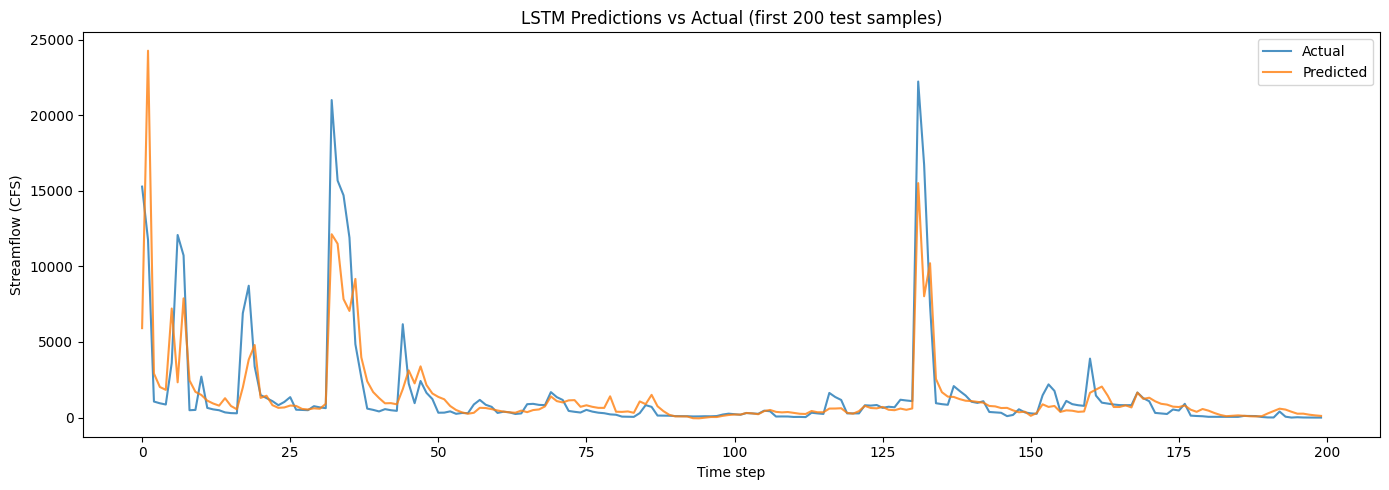

In [9]:
import matplotlib.pyplot as plt

# Evaluate on test set
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test MAE (scaled): {test_mae:.4f}")

# Convert MAE back to real CFS
mae_real = test_mae * pcr.target_scaler.scale_.item()
print(f"Test MAE (real CFS): {mae_real:.1f} CFS")

# Generate predictions
y_pred_scaled = model.predict(X_test, verbose=0)

# Inverse transform to real CFS values
y_pred_real = pcr.target_scaler.inverse_transform(
    torch.tensor(y_pred_scaled)
).numpy().flatten()

y_test_real = pcr.target_scaler.inverse_transform(
    torch.tensor(y_test)
).numpy().flatten()

# Plot first 200 predictions vs actual
plt.figure(figsize=(14, 5))
plt.plot(y_test_real[:200], label="Actual", alpha=0.8)
plt.plot(y_pred_real[:200], label="Predicted", alpha=0.8)
plt.xlabel("Time step")
plt.ylabel("Streamflow (CFS)")
plt.title("LSTM Predictions vs Actual (first 200 test samples)")
plt.legend()
plt.tight_layout()
plt.show()

Preliminary model worked well, undershooting peaks. A weighted loss function, longer window size, and log transformation on target could help. 

In [10]:
train_y_real = pcr.target_scaler.inverse_transform(torch.tensor(train_y_arr)).numpy()
val_y_real = pcr.target_scaler.inverse_transform(torch.tensor(val_y_arr)).numpy()
test_y_real = pcr.target_scaler.inverse_transform(torch.tensor(test_y_arr)).numpy()

print("Train mean streamflow:", train_y_real.mean(), "CFS")
print("Val mean streamflow:", val_y_real.mean(), "CFS")
print("Test mean streamflow:", test_y_real.mean(), "CFS")

print("\nTrain std streamflow:", train_y_real.std())
print("Val std streamflow:", val_y_real.std())
print("Test std streamflow:", test_y_real.std())

Train mean streamflow: 591.9353409650186 CFS
Val mean streamflow: 586.0113350157927 CFS
Test mean streamflow: 503.04247129290695 CFS

Train std streamflow: 2921.1793687510813
Val std streamflow: 3184.79324127489
Test std streamflow: 2264.02172962413
